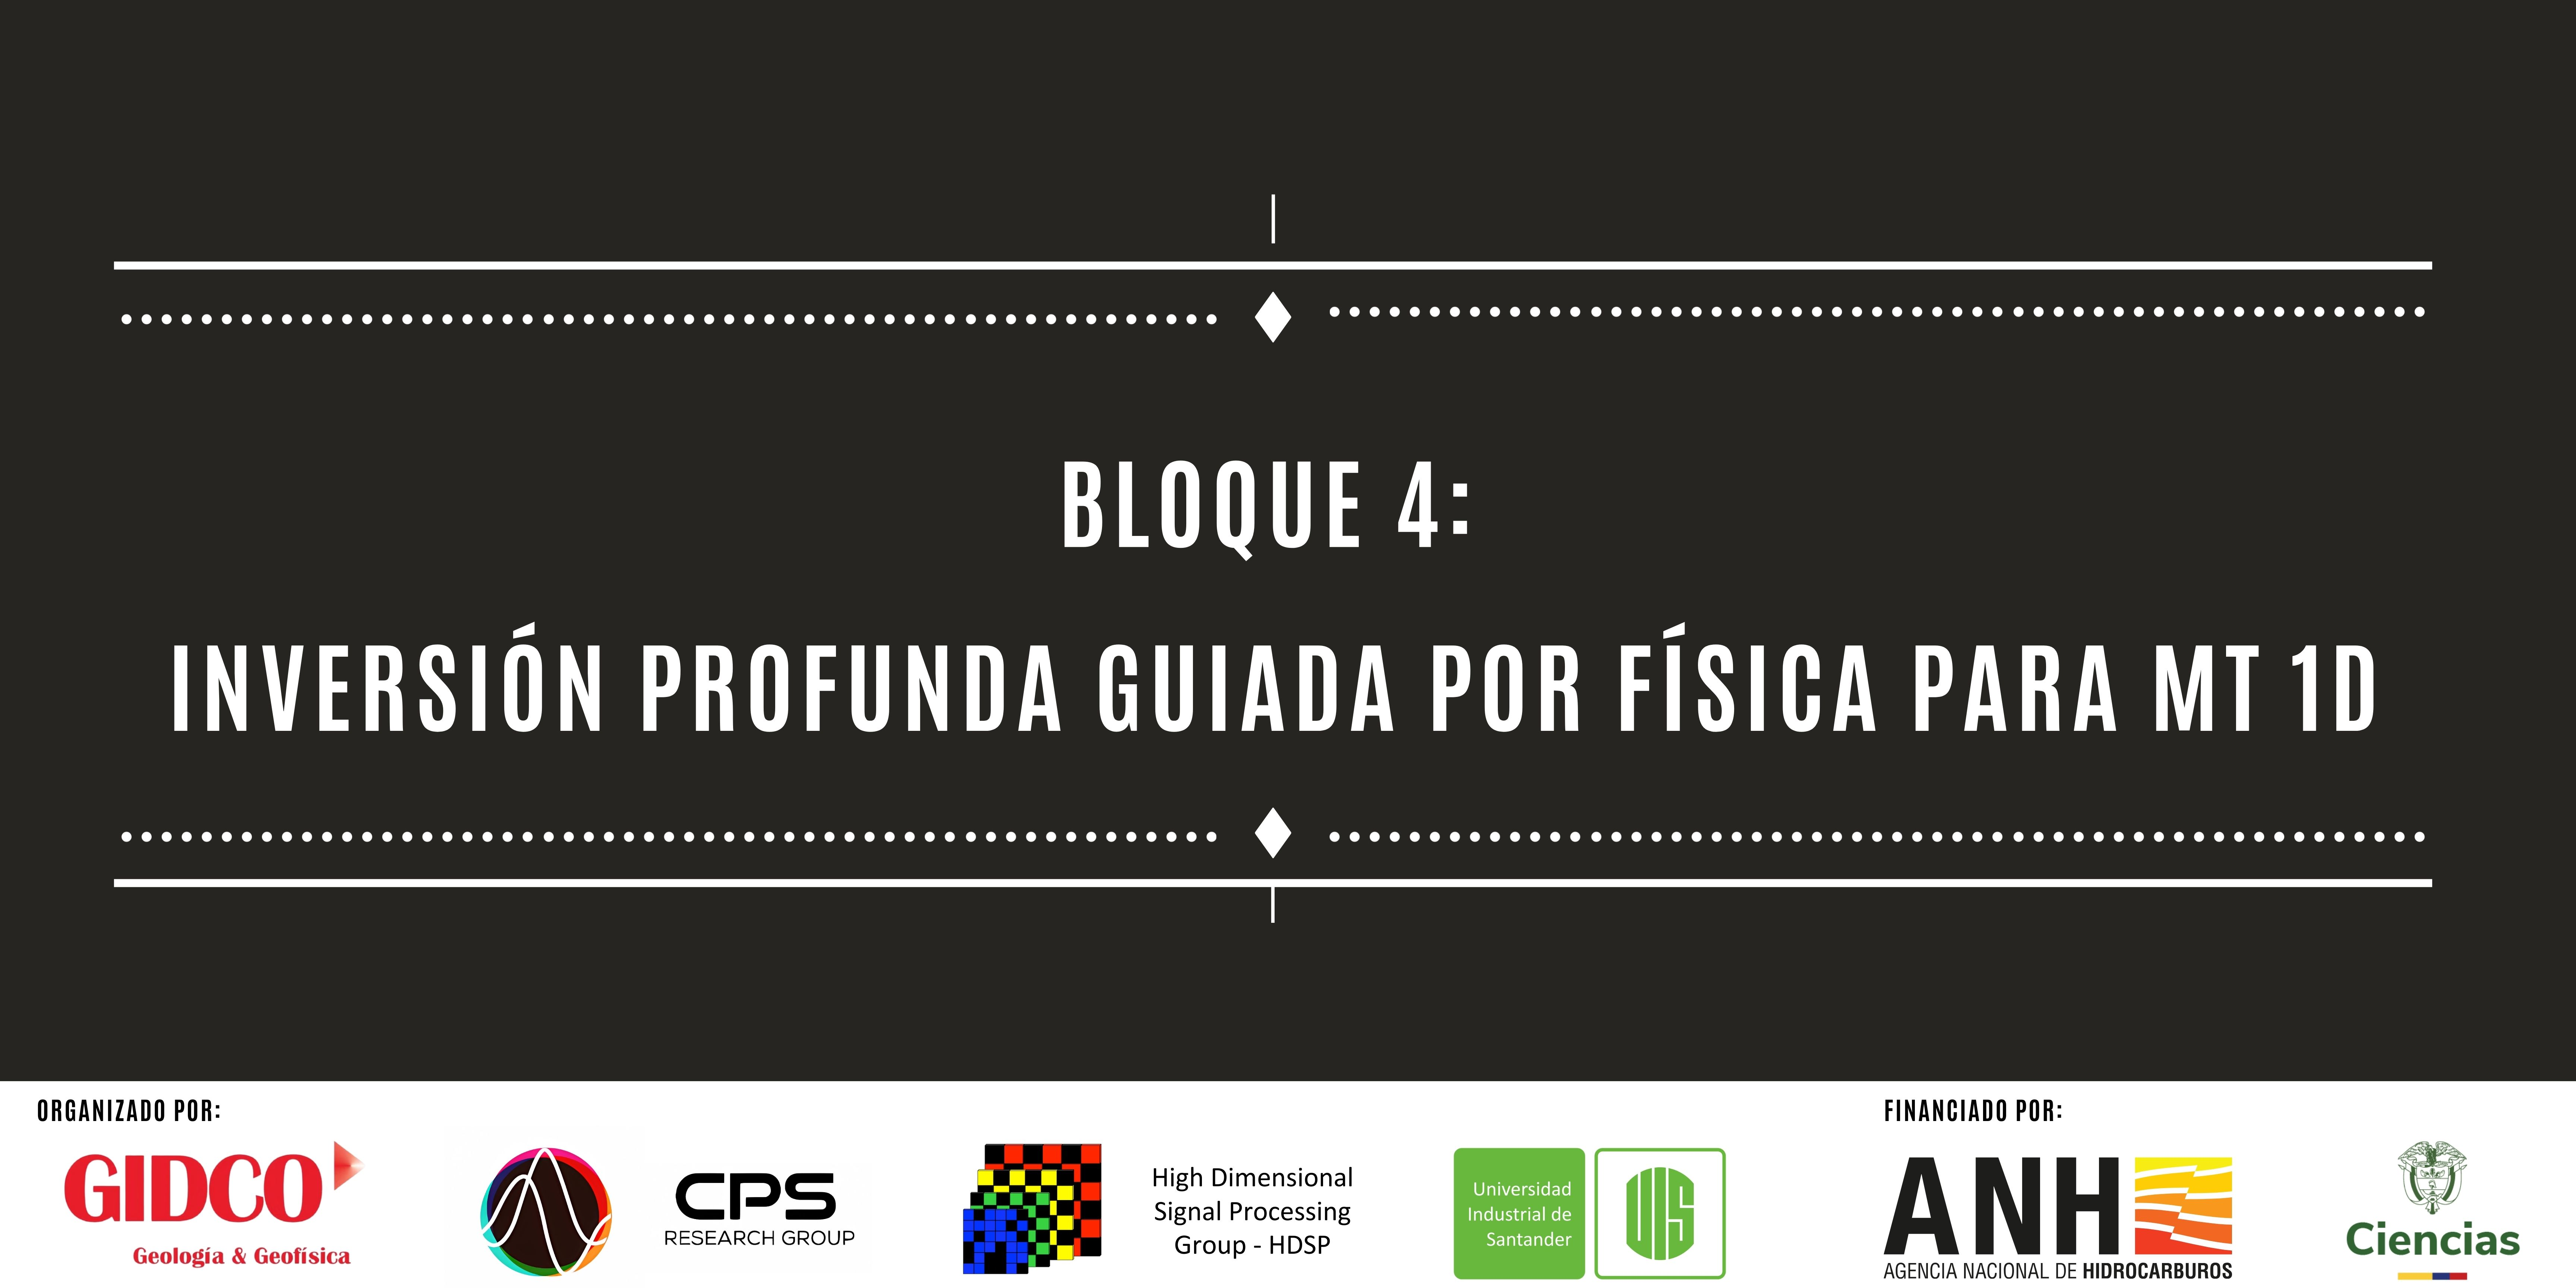

# Inversión $1$D Magnetotelúrica (MT) guiada por física — Caso sintético

Este notebook implementa un esquema de inversión magnetotelúrica (MT) $1$D guiada por física en un caso sintético.  
El objetivo es ajustar una red neuronal para predecir un modelo de resistividad por capas cuya respuesta, calculada mediante el operador directo MT, reproduzca el dato observado.

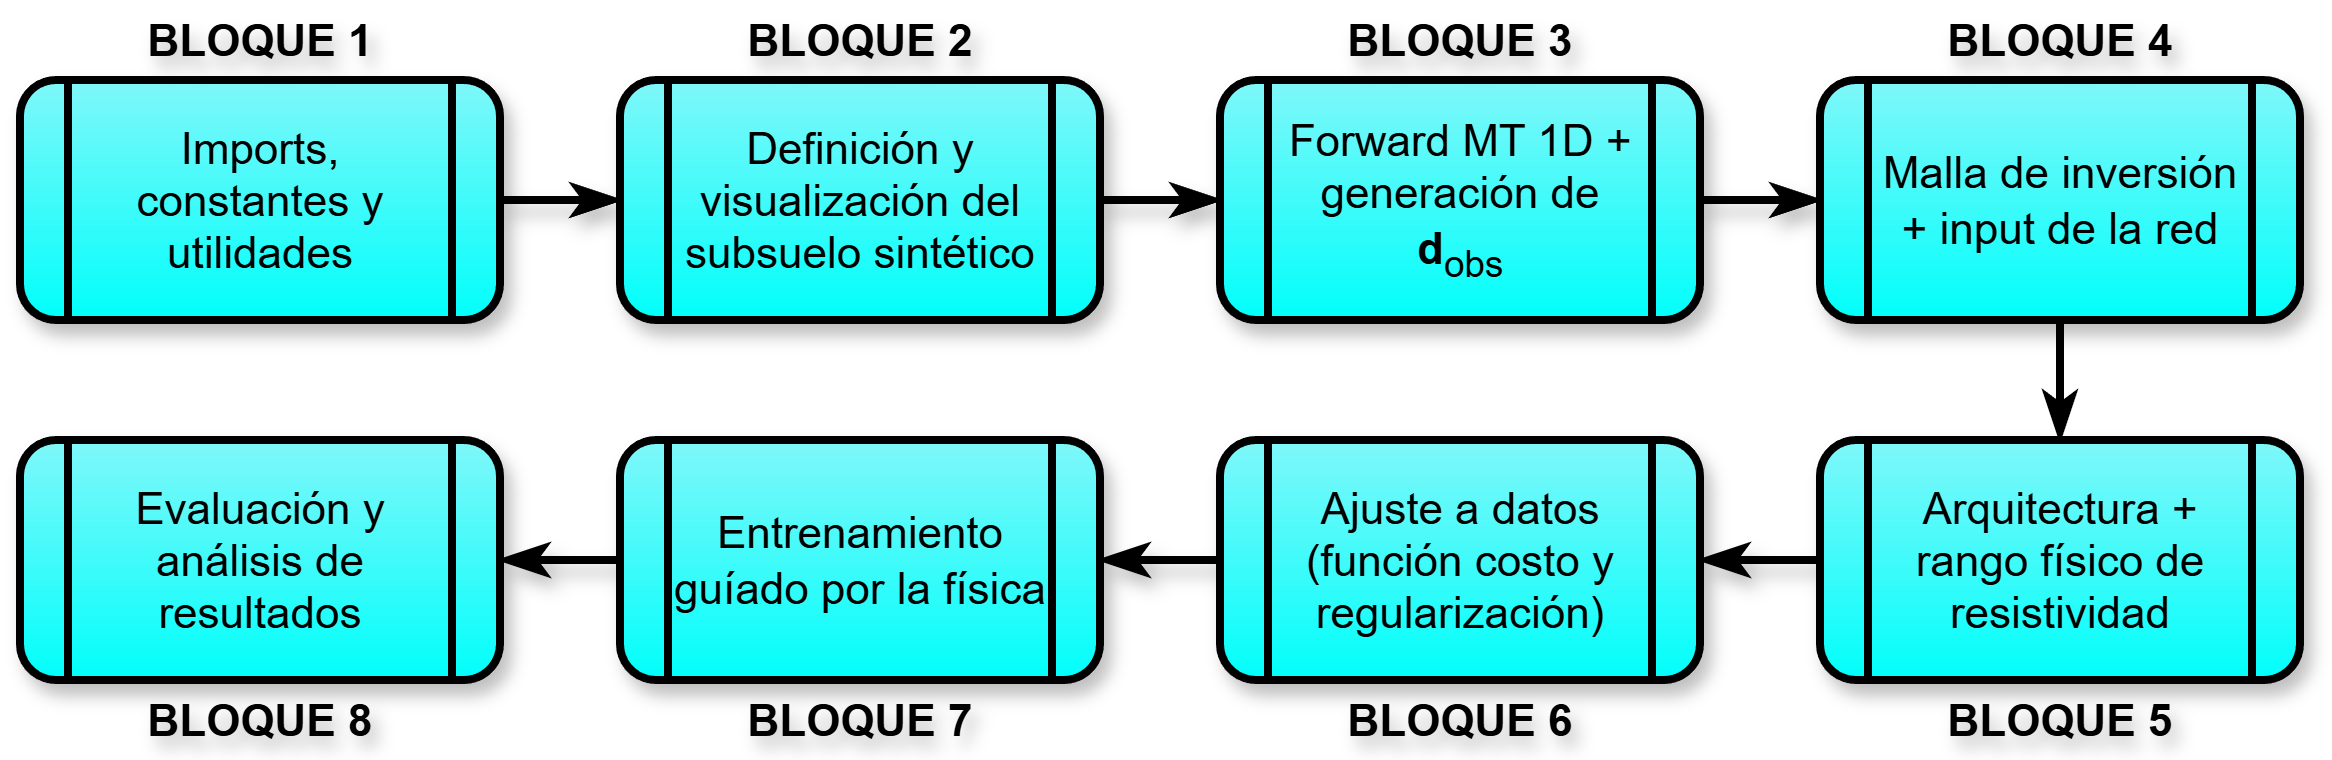

## Bloque 1. Imports, constantes y utilidades

En este bloque se prepara el entorno de trabajo del notebook.  
Se importan las librerías necesarias, se define la constante física relevante del problema y se implementan funciones auxiliares para:

- construir modelos $1$D por capas,
- generar el modelo verdadero sintético,
- crear el optimizador,
- preparar variables de entrada,
- y mapear la salida de la red neuronal al rango físico de resistividades.

In [ ]:
#@title 1) Imports
!pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import math
from scipy import constants

mu = constants.mu_0  # Permeabilidad magnética del vacío (H/m)
print("Listo")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 755.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 101.8 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Listo


In [ ]:
#@title 2) Utilidades (modelos 1D, optimizador, features)
def drawModel1D(ax, thickness, values, plot="semilogx",
                xlabel=r"Resistivity $(\Omega\,m)$", zlabel="Depth (m)", z0=0, **kwargs):
    """Dibuja un modelo 1D tipo bloque (capas)."""
    thickness = np.asarray(thickness, float)
    values = np.asarray(values, float)
    nLayers = len(values)

    px = np.zeros(nLayers * 2)
    pz = np.zeros(nLayers * 2)
    z1 = np.cumsum(thickness) + z0  # (nLayers-1,)

    for i in range(nLayers):
        px[2*i] = values[i]
        px[2*i+1] = values[i]
        if i == nLayers - 1:
            pz[2*i+1] = z1[i-1] * 1.2
        else:
            pz[2*i+1] = z1[i]
            pz[2*i+2] = z1[i]

    getattr(ax, plot)(px, pz+z0, **kwargs)
    ax.set_ylabel(zlabel)
    ax.set_xlabel(xlabel)
    ax.set_ylim(pz[-1], pz[0])
    ax.grid(True)

def make_true_model_var_thk(n_true, depthmax, seed, thk0, growth, sigma, noise_log10rho):
    """TRUE: espesores variables + resistividad plausible (resistivo–conductor–resistivo)."""
    rng = np.random.default_rng(seed)

    base = thk0 * (growth ** np.arange(n_true - 1))
    jitter = rng.lognormal(mean=0.0, sigma=sigma, size=n_true - 1)
    synthk = base * jitter
    synthk = synthk / synthk.sum() * depthmax

    t = np.linspace(0.0, 1.0, n_true)
    ctrl_t = np.array([0.0, 0.55, 1.0])
    ctrl_log10rho = np.array([2.2, 1.0, 2.8])  # ~160, 10, 630 Ohm·m
    log10rho = np.interp(t, ctrl_t, ctrl_log10rho)
    log10rho += rng.normal(0.0, noise_log10rho, size=n_true)
    synres = 10 ** log10rho

    return synres.astype(float), synthk.astype(float)

def make_optimizer(name, lr, wd=0.0, clipnorm=None):
    """Crea optimizador (compatibilidad con versiones distintas de TF/Keras)."""
    name = str(name)
    if name == "Adam":
        return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)
    if name == "RMSprop":
        return tf.keras.optimizers.RMSprop(learning_rate=lr, clipnorm=clipnorm)
    if name == "SGD":
        return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, clipnorm=clipnorm)

    try:
        return tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=wd, clipnorm=clipnorm)
    except Exception:
        try:
            return tf.keras.optimizers.experimental.AdamW(learning_rate=lr, weight_decay=wd, clipnorm=clipnorm)
        except Exception:
            print("⚠️ AdamW no disponible; usando Adam.")
            return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)

def make_features(z_complex, use_phase):
    """
    Features para la red:
    - log10|Z| (estable)
    - opcional: fase (más info)
    """
    z = np.asarray(z_complex)
    logabs = np.log10(np.abs(z) + 1e-30)
    if not use_phase:
        return logabs.astype(np.float32)
    phase = np.unwrap(np.angle(z))
    return np.concatenate([logabs, phase]).astype(np.float32)

def sigmoid_to_rho(sig, rho_min, rho_max):
    """Mapeo: sigmoid∈(0,1) -> rho en [rho_min, rho_max] en escala log10."""
    a = np.log10(rho_min)
    b = np.log10(rho_max)
    log10rho = a + sig * (b - a)
    return 10.0 ** log10rho

## Bloque 2. Definición del modelo verdadero sintético

En esta etapa se construye el modelo de referencia o **modelo verdadero (TRUE)**, representado como un medio $1$D estratificado.  
Se definen el número de capas, la profundidad total, la variación de espesores y la distribución de resistividades, para luego generar y visualizar el perfil sintético que servirá como base del experimento.

In [ ]:
#@title Parámetros del TRUE model
n_true = 6  #@param {type:"integer", min:3, max:15, step:1}
depthmax_true = 10000.0  #@param {type:"number"}
seed_true = 1234  #@param {type:"integer"}

thk0 = 120.0   #@param {type:"number"}
growth = 1.30  #@param {type:"number"}
sigma_thk = 0.35  #@param {type:"number"}

noise_log10rho = 0.08  #@param {type:"number"}

In [ ]:
#@title Construir TRUE model
synres, synthk = make_true_model_var_thk(
    n_true=n_true,
    depthmax=depthmax_true,
    seed=seed_true,
    thk0=thk0,
    growth=growth,
    sigma=sigma_thk,
    noise_log10rho=noise_log10rho,
)

print("TRUE thicknesses (m):", np.round(synthk, 2), "| sum:", np.round(synthk.sum(), 2))
print("TRUE rho (Ohm·m):    ", np.round(synres, 2))

TRUE thicknesses (m): [ 555.34 1294.29 2132.3  2256.17 3761.91] | sum: 10000.0
TRUE rho (Ohm·m):     [271.05  44.19  25.29  11.66 106.54 574.12]


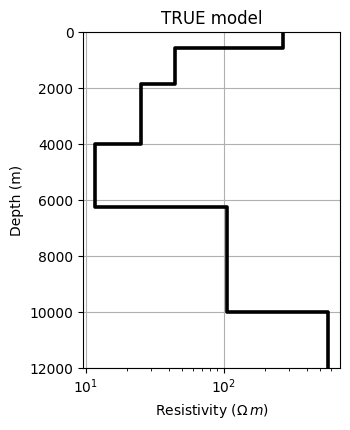

In [ ]:
#@title Plot TRUE model
fig, ax = plt.subplots(figsize=(3.6, 4.4))
drawModel1D(ax, synthk, synres, plot="semilogx", color="black", linewidth=2.6)
plt.title("TRUE model")
plt.tight_layout()
plt.show()

## Bloque 3. Generación del dato observado mediante el forward MT

En este bloque se define el rango de frecuencias del experimento y se implementa el operador directo magnetotelúrico $1$D.  
A partir del modelo verdadero, se calcula la impedancia compleja observada $Z(\omega)$, que constituye el dato sintético a reproducir durante la inversión.  
Opcionalmente, se puede añadir ruido para simular condiciones de medición más realistas.

In [ ]:
#@title Parámetros del dato observado
f_min = 1e-3  #@param {type:"number"}
f_max = 1e3   #@param {type:"number"}
n_freq = 31   #@param {type:"integer", min:5, max:200, step:1}

add_noise = False  #@param {type:"boolean"}
noise_level = 0.03  #@param {type:"number", min:0.0, max:0.3, step:0.01}
noise_seed = 2026  #@param {type:"integer"}

frequencies_np = np.logspace(np.log10(f_min), np.log10(f_max), int(n_freq)).astype(np.float64)
print("Freqs:", frequencies_np[0], "→", frequencies_np[-1], "Hz | n =", len(frequencies_np))

Freqs: 0.001 → 1000.0 Hz | n = 31


### Operador directo MT $1$D

Calcula $Z(\omega)$ para un modelo $1$D estratificado.  
Este operador es el núcleo físico que conecta la predicción del modelo de resistividad con la respuesta magnetotelúrica observada.

In [ ]:
#@title Forward MT 1D (TensorFlow)
@tf.function
def MTforwardModelTF2(thicknesses_real, resistivities_real):
    frequencies = tf.cast(frequencies_np, dtype=tf.complex128)
    thicknesses = tf.cast(thicknesses_real, dtype=tf.complex128)
    resistivities = tf.cast(resistivities_real, dtype=tf.complex128)
    n = resistivities.shape[0]

    Z_out = tf.TensorArray(dtype=tf.complex128, size=0, dynamic_size=True)

    for frequency in frequencies:
        w = tf.cast(2.0 * math.pi, tf.complex128) * frequency
        impedances = tf.TensorArray(dtype=tf.complex128, size=n)

        impedances = impedances.write(n - 1, tf.sqrt(w * mu * 1j * resistivities[n - 1]))

        for j in range(n - 2, -1, -1):
            rho = resistivities[j]
            h = thicknesses[j]

            dj = tf.sqrt((w * mu * (1.0 / rho)) * 1j)
            wj = dj * rho
            ej = tf.exp(-2.0 * h * dj)

            Z_below = impedances.read(j + 1)
            rj = (wj - Z_below) / (wj + Z_below)
            re = rj * ej
            Zj = wj * ((1.0 - re) / (1.0 + re))
            impedances = impedances.write(j, Zj)

        Z_out = Z_out.write(Z_out.size(), impedances.read(0))

    return Z_out.stack()

print("Forward listo")

Forward listo


In [ ]:
#@title Generar dato observado z_obs (desde TRUE)
z_obs = MTforwardModelTF2(synthk, synres)

if add_noise:
    rng = np.random.default_rng(noise_seed)
    eps = noise_level * (
        rng.standard_normal(len(frequencies_np)) + 1j * rng.standard_normal(len(frequencies_np))
    )
    z_obs = tf.cast(z_obs.numpy() * (1.0 + eps), tf.complex128)

print("z_obs generado")

z_obs generado


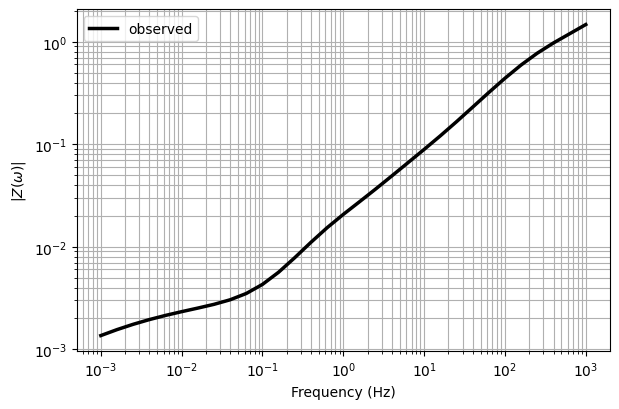

In [ ]:
#@title Plot dato observado |Z|
fig, ax = plt.subplots(figsize=(6.3, 4.2))
ax.loglog(frequencies_np, np.abs(z_obs.numpy()), "k", lw=2.5, label="observed")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"$|Z(\omega)|$")
ax.grid(True, which="both")
ax.legend()
plt.tight_layout()
plt.show()

## Bloque 4. Parametrización del modelo de inversión y construcción del input

Aquí se define la malla de inversión sobre la cual se estimará el modelo de resistividad.  
A diferencia del modelo verdadero, esta parametrización suele tener más capas para dar mayor flexibilidad a la solución.  
Además, se construye la entrada de la red neuronal a partir del dato observado, usando en este caso la magnitud de la impedancia $|Z(\omega)|$.

### Malla de inversión

- **n_layer**: número de resistividades a estimar.  
- **dz**: espesor superficial.  
- **z_factor**: crecimiento geométrico de espesores con la profundidad.

In [ ]:
#@title Parámetros de malla de inversión
dz = 100.0  #@param {type:"number"}
n_layer = 20  #@param {type:"integer", min:4, max:80, step:1}
z_factor = 1.165  #@param {type:"number", min:1.05, max:2.0, step:0.01}

layer_thicknesses_inv = (dz * (z_factor ** np.arange(n_layer - 1))).astype(np.float64)
print("INV sum thickness (m):", float(layer_thicknesses_inv.sum()))

INV sum thickness (m): 10427.320961892161


### Construcción del input

La red recibe como entrada la magnitud de la impedancia observada, $|Z(\omega)|$, organizada como un vector de características.

In [ ]:
#@title Construir input x_in = |Z|
x_in_np = np.abs(z_obs.numpy()).astype(np.float32)
x_in = tf.constant(x_in_np.reshape(1, -1), dtype=tf.float32)
print("Input dim =", x_in.shape[1], "| rango |Z|:", float(x_in_np.min()), "→", float(x_in_np.max()))

Input dim = 31 | rango |Z|: 0.0013589949812740088 → 1.4711127281188965


## Bloque 5. Definición del modelo neuronal y restricciones físicas

En esta sección se define la arquitectura de la red neuronal encargada de predecir el modelo de resistividad.  
También se establece el rango físico permitido para las resistividades, de forma que la salida de la red, originalmente acotada por una función sigmoide, pueda transformarse a valores geológicamente razonables.

### Arquitectura de la red

- **neurons**: tamaño de la capa oculta.  
- **n_res_blocks**: número de bloques residuales.  
- **use_residual**: activa o desactiva conexiones residuales.  
- **l1_strength**: regularización L1 sobre los pesos.

In [ ]:
#@title Hiperparámetros de la red
neurons = 256  #@param {type:"integer", min:16, max:1024, step:16}
n_res_blocks = 5  #@param {type:"integer", min:0, max:20, step:1}
activation = "relu"  #@param ["relu","elu","tanh","swish"]
use_residual = True  #@param {type:"boolean"}
l1_strength = 1e-6  #@param {type:"number"}

In [ ]:
#@title Construir la red
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import l1

tf.keras.backend.clear_session()
tf.random.set_seed(0)

input_dim = int(x_in.shape[1])
output_dim = int(n_layer)

def build_model(input_dim, output_dim, neurons, n_res_blocks, activation, use_residual, l1_strength):
    inp = Input(shape=(input_dim,))
    x = Dense(neurons, activation=activation)(inp)
    for _ in range(n_res_blocks):
        h = Dense(neurons, activation=activation, kernel_regularizer=l1(l1_strength))(x)
        x = keras.layers.add([x, h]) if use_residual else h
    out = Dense(output_dim, activation="sigmoid")(x)
    return keras.Model(inp, out)

MTaeNET = build_model(
    input_dim, output_dim, neurons, n_res_blocks, activation, use_residual, l1_strength
)
MTaeNET.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      8,192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ add[0][0],        │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256)       │          0 │ add_1[0][0],      │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     65,792 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ add_3[0][0],      │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 20)        │      5,140 │ add_4[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 342,292 (1.31 MB)

 Trainable params: 342,292 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

### Rango físico de resistividad

La red produce valores en $(0,1)$ mediante una sigmoide, y estos se transforman a resistividades dentro del intervalo $[\rho_{\min}, \rho_{\max}]$ en escala logarítmica.  
Si el modelo verdadero cae fuera de este rango, la inversión tenderá a saturarse en los límites.

In [ ]:
#@title Rango permitido de resistividad (Ohm·m)
rho_min = 1.0     #@param {type:"number"}
rho_max = 1000.0  #@param {type:"number"}
print("rho in [", rho_min, ",", rho_max, "] Ohm·m")

rho in [ 1.0 , 1000.0 ] Ohm·m


## Bloque 6. Definición de la función de costo guiada por física

En este bloque se formula la función objetivo que guía el proceso de inversión.  
La pérdida total combina dos contribuciones:

- un término de ajuste a datos, que mide la diferencia entre la respuesta observada y la respuesta predicha por el forward MT;
- y un término de suavidad, que actúa como regularización sobre el modelo de resistividad estimado.

Esta formulación permite incorporar conocimiento físico del problema dentro del entrenamiento de la red.

### Función de costo

- **loss_data**: usa el logaritmo complejo de $Z$, incorporando simultáneamente magnitud y fase.  
- **loss_smooth**: penaliza variaciones abruptas en $\log(\rho)$.  
- **smooth_weight**: controla el peso relativo de la regularización.

In [ ]:
#@title Regularización (suavidad)
smooth_weight = 0.1  #@param {type:"number"}
print("smooth_weight =", smooth_weight)

smooth_weight = 0.1


$$
\min_{\boldsymbol{\theta}} \; \mathcal{L}(\boldsymbol{\theta})
=
\mathcal{L}_d(\boldsymbol{\theta}) + \lambda \, \mathcal{L}_s(\boldsymbol{\theta})
$$

$$
\mathcal{L}_d(\boldsymbol{\theta})
=
\frac{1}{2}
\left\|
\log\!\left(Z_{\mathrm{obs}}\right)
-
\log\!\left(Z_{\mathrm{pred}}(\boldsymbol{\theta})\right)
\right\|_2^2
$$

$$
\mathcal{L}_s(\boldsymbol{\theta})
=
\left\|
\dfrac{
\log\!\left(\rho_{i+1}(\boldsymbol{\theta})\right)
-
\log\!\left(\rho_i(\boldsymbol{\theta})\right)
}{
\log(h_i)
}
\right\|_2^2
$$

In [ ]:
#@title Definir loss_data + loss_smooth
def loss_smooth(res_pred, thicknesses_inv):
    logrho = tf.reshape(tf.math.log(res_pred + 1e-30), (-1,))
    diff = logrho[1:] - logrho[:-1]
    denom = tf.math.log(tf.constant(thicknesses_inv, dtype=tf.float32) + 1e-12)
    r = diff / (denom + 1e-12)
    return tf.reduce_sum(tf.square(r))

def loss_data_complex_log(z_obs_c, z_pred_c):
    eps = tf.complex(tf.constant(1e-30, tf.float64), tf.constant(0.0, tf.float64))
    r = tf.math.log(z_obs_c + eps) - tf.math.log(z_pred_c + eps)
    return 0.5 * tf.reduce_sum(tf.square(tf.abs(r)))

print("Loss definida")

Loss definida


## Bloque 7. Entrenamiento del modelo

En esta etapa se ajustan los parámetros de la red neuronal mediante optimización iterativa.  
En cada iteración, la red predice un modelo de resistividad, este modelo se transforma en una respuesta magnetotelúrica mediante el operador directo, y la diferencia con el dato observado se evalúa a través de la función de costo definida anteriormente.

El objetivo del entrenamiento es encontrar un modelo cuya respuesta reproduzca de la mejor manera posible la impedancia observada, manteniendo al mismo tiempo una solución estable y suave.

### Parámetros de entrenamiento

- **epochs**: número de iteraciones.  
- **learning_rate**: tasa de aprendizaje.  
- **optimizer_name**: optimizador utilizado.  
- **weight_decay**: regularización sobre los pesos.  
- **clipnorm**: estabilización de gradientes.

In [ ]:
#@title Parámetros de entrenamiento
epochs = 200  #@param {type:"integer", min:10, max:5000, step:10}
learning_rate = 1e-3  #@param {type:"number"}
optimizer_name = "AdamW"  #@param ["Adam","AdamW","RMSprop","SGD"]
weight_decay = 1e-4  #@param {type:"number"}
clipnorm = 1.0  #@param {type:"number"}

In [ ]:
#@title Ejecutar entrenamiento
opt = make_optimizer(optimizer_name, learning_rate, wd=weight_decay, clipnorm=clipnorm)

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        sig = tf.reshape(MTaeNET(x_in, training=True), (-1,))

        a = tf.constant(np.log10(rho_min), tf.float32)
        b = tf.constant(np.log10(rho_max), tf.float32)
        log10rho = a + sig * (b - a)
        res_pred = tf.pow(tf.constant(10.0, tf.float32), log10rho)

        z_pred = MTforwardModelTF2(layer_thicknesses_inv, tf.cast(res_pred, tf.float64))
        z_obs_c = tf.cast(z_obs, tf.complex128)

        Ld = loss_data_complex_log(z_obs_c, z_pred)
        Ls = loss_smooth(res_pred, layer_thicknesses_inv)
        L = Ld + tf.cast(smooth_weight * Ls, tf.float64)

    grads = tape.gradient(L, MTaeNET.trainable_weights)
    opt.apply_gradients(zip(grads, MTaeNET.trainable_weights))
    return L, Ld, Ls

loss_hist, Ld_hist, Ls_hist = [], [], []
for it in range(int(epochs)):
    L, Ld, Ls = train_step()
    loss_hist.append(float(L.numpy()))
    Ld_hist.append(float(Ld.numpy()))
    Ls_hist.append(float(Ls.numpy()))

print("Entrenamiento terminado")
print("Final | Loss:", loss_hist[-1], "| Data:", Ld_hist[-1], "| Smooth:", Ls_hist[-1])

Entrenamiento terminado
Final | Loss: 0.013248258303185963 | Data: 0.001173678818425202 | Smooth: 0.12074579298496246


## Bloque 8. Evaluación y análisis de resultados

Finalmente, se analiza el desempeño de la inversión desde tres perspectivas complementarias:

1. la evolución de la función de costo durante el entrenamiento,
2. el ajuste entre la respuesta observada y la respuesta predicha,
3. y la comparación entre el modelo verdadero y el modelo invertido.

Además, se calculan métricas cuantitativas sobre $\log |Z|$ para resumir la calidad final del ajuste.

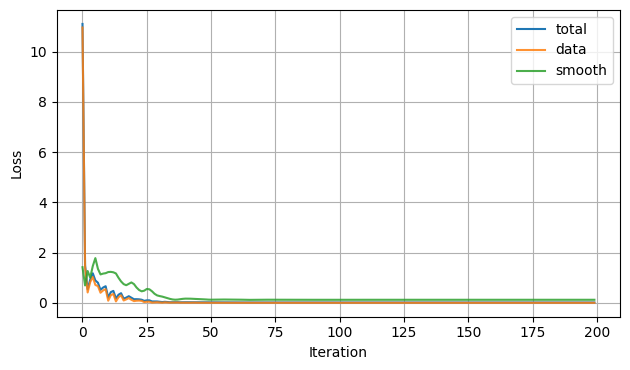

In [ ]:
#@title Plot evolución de pérdidas
plt.figure(figsize=(6.4, 3.8))
plt.plot(loss_hist, label="total")
plt.plot(Ld_hist, label="data", alpha=0.85)
plt.plot(Ls_hist, label="smooth", alpha=0.85)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

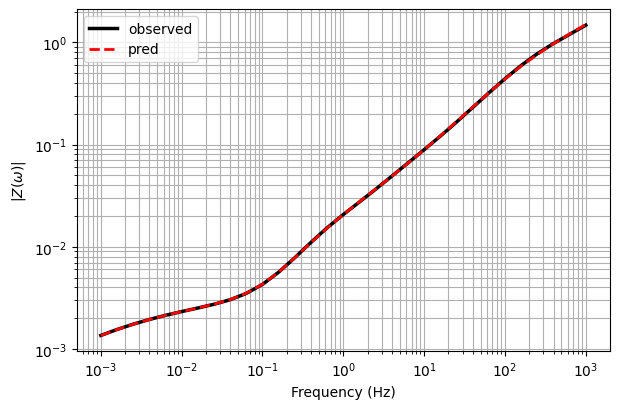

In [ ]:
#@title Plot |Z| observado vs predicho
sig_np = MTaeNET(x_in, training=False).numpy().reshape(-1)
res_pred_np = sigmoid_to_rho(sig_np, rho_min, rho_max)
z_pred_np = MTforwardModelTF2(layer_thicknesses_inv, res_pred_np).numpy()

fig, ax = plt.subplots(figsize=(6.3, 4.2))
ax.loglog(frequencies_np, np.abs(z_obs.numpy()), "k", lw=2.5, label="observed")
ax.loglog(frequencies_np, np.abs(z_pred_np), "--r", lw=2.0, label="pred")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"$|Z(\omega)|$")
ax.grid(True, which="both")
ax.legend()
plt.tight_layout()
plt.show()

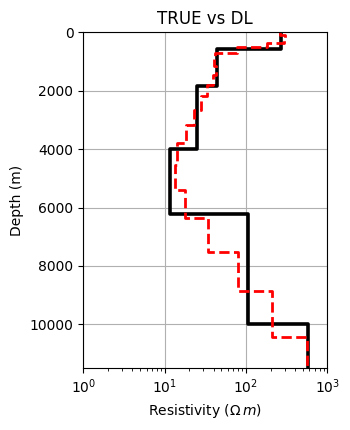

In [ ]:
#@title Plot TRUE vs modelo invertido
fig, ax = plt.subplots(figsize=(3.6, 4.4))
drawModel1D(ax, synthk, synres, plot="semilogx", color="black", linewidth=2.6)
drawModel1D(ax, layer_thicknesses_inv, res_pred_np, plot="semilogx",
            color="red", linestyle="dashed", linewidth=2.0)
plt.xlim([rho_min, rho_max])
plt.ylim([max(depthmax_true * 1.15, layer_thicknesses_inv.sum() * 1.1), 0])
plt.title("TRUE vs DL")
plt.tight_layout()
plt.show()

### Métricas de ajuste

Al final se evalúa el ajuste entre la respuesta observada y la predicha usando tres métricas calculadas sobre $\log |Z(\omega)|$.

**¿Por qué en $\log |Z|$?**  
Porque la magnitud de la impedancia suele variar varios órdenes de magnitud con la frecuencia, por lo que la comparación en escala logarítmica resulta más equilibrada.

**Métricas utilizadas:**
- **RMSE($\log |Z|$)**: error cuadrático medio.  
- **MAE($\log |Z|$)**: error absoluto medio.  
- **R²($\log |Z|$)**: proporción de la variabilidad explicada por el modelo.

In [ ]:
#@title Métricas sobre log|Z|
import pandas as pd

Zobs = z_obs.numpy()
Zprd = z_pred_np

Aobs = np.abs(Zobs)
Aprd = np.abs(Zprd)

logAobs = np.log(np.maximum(Aobs, np.finfo(float).tiny))
logAprd = np.log(np.maximum(Aprd, np.finfo(float).tiny))

rmse_logabs = np.sqrt(np.mean((logAprd - logAobs)**2))
mae_logabs  = np.mean(np.abs(logAprd - logAobs))

ss_res = np.sum((logAprd - logAobs)**2)
ss_tot = np.sum((logAobs - np.mean(logAobs))**2)
r2_logabs = 1.0 - ss_res / np.maximum(ss_tot, np.finfo(float).tiny)

df = pd.DataFrame({
    "Métrica": ["RMSE(log|Z|)", "MAE(log|Z|)", "R²(log|Z|)"],
    "Valor":  [rmse_logabs, mae_logabs, r2_logabs]
})

df_show = df.copy()
df_show["Valor"] = df_show["Valor"].map(lambda x: f"{x:.6g}")

display(
    df_show.style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
    .hide(axis="index")
)

Métrica,Valor
RMSE(log|Z|),0.00642708
MAE(log|Z|),0.00475753
R²(log|Z|),0.999992
